In [1]:
# notebook to define a set of eQTLs for comparison on an independent set
# gtex v10
# updates from previous analyses:
# 

In [1]:
# import packages
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from collections import Counter
import numpy as np
from sklearn import metrics
from collections import Counter
from sklearn.metrics import RocCurveDisplay
import matplotlib.patches as mpatches
import pybedtools

In [2]:
# define the path to the fine mapped variants as a variable
path2fineMapped = 'raw_data/gtex_v10_fineMapping/SuSiE_fineMapped'
# define the path to the gtex info as a variable
path2gtex_v10 = 'raw_data/gtex_v10_fineMapping/GTEx_Analysis_v10_eQTL_updated'

In [3]:
# iterate through all fine mapped variants and collapse into a single DF
fineMapped2cat = []
for i in tqdm([i for i in os.listdir(path2fineMapped) if i.endswith('.parquet')]):
    parqLife = pd.read_parquet(f'{path2fineMapped}/{i}')
    # add tissue column
    parqLife.loc[:,'tissue'] = [i.split('.')[0] for j in range(len(parqLife))]
    # combine the variant_id and the tissue id for filtering downstream
    parqLife.loc[:, 'filter_id'] = [('_').join([id, tissue, gene]) for id, tissue, gene in zip(parqLife['variant_id'], parqLife['tissue'], parqLife['phenotype_id'])]                                                                                                                                                                         
    fineMapped2cat.append(parqLife)
# make df
fineMapped_all = pd.concat(fineMapped2cat)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:15<00:00,  3.17it/s]


In [4]:
# iterate through all significant associations 
gtex2cat = []
for i in tqdm([i for i in os.listdir(path2gtex_v10) if i.endswith('.parquet')]):
    parqLife = pd.read_parquet(f'{path2gtex_v10}/{i}')
    # add tissue column
    parqLife.loc[:,'tissue'] = [i.split('.')[0] for j in range(len(parqLife))]
    # combine the variant_id and the tissue id for filtering downstream
    parqLife.loc[:, 'filter_id'] = [('_').join([id, tissue, gene]) for id, tissue, gene in zip(parqLife['variant_id'], parqLife['tissue'], parqLife['gene_id'])]                                                                                                                                                                         
    gtex2cat.append(parqLife)
# make df
gtex_v10_all = pd.concat(gtex2cat)
# add absolute distance to the tss
gtex_v10_all.loc[:, 'abs_tss_dist'] = [abs(i) for i in gtex_v10_all['tss_distance']]

100%|██████████| 50/50 [02:08<00:00,  2.58s/it]


In [5]:
# get the high pip variants from fine mapping data
high_PIP_vars = fineMapped_all[fineMapped_all['pip'] >= 0.9]
# get the variant IDs
# original ID
high_PIP_varIDs = high_PIP_vars['variant_id'].tolist()
# tissue_ID
high_PIP_filterIDs = high_PIP_vars['filter_id'].tolist()

In [6]:
# filter GTEx data for TSS distance BEFORE calculating mean slopes
gtex_v10_all_filtered = gtex_v10_all[gtex_v10_all['abs_tss_dist'] <= 250]
# use filtered version for calculating mean slope
gtex_v10_highPIP = gtex_v10_all_filtered[gtex_v10_all_filtered['filter_id'].isin(high_PIP_filterIDs)]
# Calculate mean slope from filtered data
gtex_v10_highPIP_all_tissues_meanSlope = gtex_v10_highPIP.filter(['gene_id', 'tissue', 'variant_id', 'pip', 'slope']).groupby(['variant_id', 'gene_id'])[['slope']].mean().reset_index()

In [7]:
# open all promoter predictions
promoter_preds_df = pd.read_csv('processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut.v2.tsv', sep = '\t')
# add mean mpac skew :/
promoter_preds_df.loc[:, 'mpac_mean_skew'] = [np.mean([k,h,s]) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max mpac skew
promoter_preds_df.loc[:, 'mpac_max_skew'] = [max([k,h,s], key=abs) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max parm skew
promoter_preds_df.loc[:, 'parm_max_skew'] = [max([k,h], key=abs) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add mean parm skew
promoter_preds_df.loc[:, 'parm_mean_skew'] = [np.mean([k,h]) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add ID for merging wth phyloP scores
promoter_preds_df.loc[:, 'var_id'] = [(':').join([chrom, str(pos), ref, alt]) for chrom, pos, ref, alt in zip(promoter_preds_df['chrom'], promoter_preds_df['pos'], promoter_preds_df['ref'], promoter_preds_df['alt'])]
# # open phyloP annotated variants and add phyloP scores
# phylo470 = pd.read_csv('processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.v2.vcf', sep = '\t', comment = '#', header = None)
# # drop missing values
# phylo470 = phylo470[phylo470[7] != '.']
# # build dictionary for adding 
# phylo470_dict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phylo470[0], 
#                                                                                                  phylo470[1], 
#                                                                                                  phylo470[3], 
#                                                                                                  phylo470[4])],
#                      [float(i.split('=')[-1]) for i in phylo470[7]]))
# # add 470-way phyloP score
# promoter_preds_df.loc[:, 'phyloP_470'] = [phylo470_dict.get(i) for i in promoter_preds_df['var_id']]
# first lets do all correlations at the nucleotide level
# some positions are NAs in promoterAI, we will drop those for this analysis
# we'll also drop those predictions without phyloP scores
# filter for those
promoterAI_filtered_preds = promoter_preds_df.dropna().copy()
# add a gtex id to the promoter preds
promoterAI_filtered_preds.loc[:,'gtex_id'] = [f'{('_').join([chrom, str(pos), ref, alt])}_b38' for chrom, pos, ref, alt in zip(promoterAI_filtered_preds['chrom'],
                                                                                                                             promoterAI_filtered_preds['pos'],
                                                                                                                             promoterAI_filtered_preds['ref'],
                                                                                                                             promoterAI_filtered_preds['alt'])]

In [8]:
# all tissues
highPIP_all_tissue_preds = promoterAI_filtered_preds[promoterAI_filtered_preds['gtex_id'].isin(gtex_v10_highPIP_all_tissues_meanSlope['variant_id'].tolist())].copy()
# make a dictionary of the average slopes
allTissues_slope_dict = dict(zip(gtex_v10_highPIP_all_tissues_meanSlope['variant_id'],
                               gtex_v10_highPIP_all_tissues_meanSlope['slope']))
# add slope to each df
highPIP_all_tissue_preds.loc[:, 'slope'] = [allTissues_slope_dict.get(i) for i in highPIP_all_tissue_preds['gtex_id']]
# drop duplicate instances of the same variant
highPIP_all_tissue_preds = highPIP_all_tissue_preds.drop_duplicates(subset='var_id')

In [23]:
# get genes with at least one high PIP variant
genes_with_high_PIP = high_PIP_vars['phenotype_id'].unique()
# get variant ids for those with at least one high PIP variant
high_PIP_variant_ids = high_PIP_vars['variant_id'].unique().tolist()
# get fine mapped variants in those genes
fineMapped_in_high_PIP_genes = fineMapped_all[fineMapped_all['phenotype_id'].isin(genes_with_high_PIP)]
# check if PIP < 0.1 in ALL tissues
# group by variant_id and phenotype_id to get max PIP across all tissues
variant_max_pip = fineMapped_in_high_PIP_genes.groupby(['variant_id', 'phenotype_id'])['pip'].max().reset_index()
variant_max_pip.columns = ['variant_id', 'phenotype_id', 'max_pip']
# identify null variants: max PIP < 0.1 across all tissues AND not a high-PIP variant for any gene
null_variants = variant_max_pip[
    (variant_max_pip['max_pip'] < 0.1) & 
    (~variant_max_pip['variant_id'].isin(high_PIP_variant_ids))
]
# filter null variants for TSS distance <= 500bp
gtex_v10_null_temp = gtex_v10_all[gtex_v10_all['variant_id'].isin(null_variants['variant_id'])]
# filter for abs_tss_dist <= 500
gtex_v10_null_filtered = gtex_v10_null_temp[gtex_v10_null_temp['abs_tss_dist'] <= 500]
# get unique gene-variant pairs to prevent overlap of high PIP for one gene but low for another
null_variants_near_tss = gtex_v10_null_filtered[['variant_id', 'gene_id']].drop_duplicates()
# filter null_variants to only include those within 500bp
null_variants = null_variants.merge(
    null_variants_near_tss,
    left_on=['variant_id', 'phenotype_id'],
    right_on=['variant_id', 'gene_id'],
    how='inner'
).drop(columns=['gene_id'])
# select one variant per gene (the one with lowest mean PIP)
# calculate mean PIP across all tissues for each variant
variant_mean_pip = fineMapped_in_high_PIP_genes.groupby(['variant_id', 'phenotype_id'])['pip'].mean().reset_index()
variant_mean_pip.columns = ['variant_id', 'phenotype_id', 'mean_pip']
# add mean PIP to potential null variants
null_variants_with_mean = null_variants.merge(
    variant_mean_pip[['variant_id', 'phenotype_id', 'mean_pip']], 
    on=['variant_id', 'phenotype_id']
)
# for each gene, select the variant with the lowest mean PIP
null_variants_balanced = null_variants_with_mean.loc[
    null_variants_with_mean.groupby('phenotype_id')['mean_pip'].idxmin()
]
# get variant IDs of null candidates
null_varIDs = null_variants_balanced['variant_id'].unique().tolist()
# filter gtex data for null variants to calculate mean slope
gtex_v10_null = gtex_v10_null_filtered[gtex_v10_null_filtered['variant_id'].isin(null_varIDs)]
# calculate mean slope across tissues (same approach as high PIP)
gtex_v10_null_all_tissues_meanSlope = gtex_v10_null.filter(
    ['gene_id', 'tissue', 'variant_id', 'slope']
).groupby(['variant_id', 'gene_id'])[['slope']].mean().reset_index()
# get predictions
null_variant_preds = promoterAI_filtered_preds[
    promoterAI_filtered_preds['gtex_id'].isin(null_varIDs)
]
# add slope to null variants
null_slope_dict = dict(zip(
    gtex_v10_null_all_tissues_meanSlope['variant_id'],
    gtex_v10_null_all_tissues_meanSlope['slope']
))

null_variant_preds.loc[:, 'slope'] = [
    null_slope_dict.get(i) for i in null_variant_preds['gtex_id']
]
# drop duplicates
null_variant_preds = null_variant_preds.drop_duplicates(subset='var_id')
# ceate combined benchmark dataset
# add variant type labels
highPIP_all_tissue_preds.loc[:, 'variant_type'] = 'high_PIP'
null_variant_preds.loc[:, 'variant_type'] = 'null'
# label high PIP variants as under/overexpression
highPIP_all_tissue_preds.loc[:, 'eQTL_type'] = [
    'underexpression' if s < 0 else 'overexpression' 
    for s in highPIP_all_tissue_preds['slope']
]
null_variant_preds.loc[:, 'eQTL_type'] = 'null'
# concatenate predictions together for plotting, etc.
gtex_eQTL_benchmark = pd.concat([
    highPIP_all_tissue_preds,
    null_variant_preds
], ignore_index=True)
# print summary
print(f"\nBenchmark dataset summary:")
print(gtex_eQTL_benchmark['variant_type'].value_counts())
print(f"\neQTL type breakdown:")
print(gtex_eQTL_benchmark['eQTL_type'].value_counts())


Benchmark dataset summary:
variant_type
null        543
high_PIP    504
Name: count, dtype: int64

eQTL type breakdown:
eQTL_type
null               543
overexpression     257
underexpression    247
Name: count, dtype: int64


/tmp/ipykernel_2588562/1254223886.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  null_variant_preds.loc[:, 'slope'] = [


In [12]:
gtex_eQTL_benchmark.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,parm_emVar_any,mpac_mean_skew,mpac_max_skew,parm_max_skew,parm_mean_skew,var_id,gtex_id,slope,variant_type,eQTL_type
0,chr1,966426,ENSG00000187583.11_ENST00000379410.8_PLEKHN1.....,G,C,2.774934,3.561293,0.786360,2.621628,2.851770,...,0,0.365436,0.786360,0.025524,0.002440,chr1:966426:G:C,chr1_966426_G_C_b38,0.365988,high_PIP,overexpression
1,chr1,2019112,ENSG00000187730.9_ENST00000378585.7_GABRD..chr...,G,A,2.087069,2.153853,0.066784,1.597651,1.645369,...,0,0.072020,0.101557,0.010694,0.000740,chr1:2019112:G:A,chr1_2019112_G_A_b38,0.303898,high_PIP,overexpression
2,chr1,3796509,ENSG00000130764.10_ENST00000378251.3_LRRC47..c...,C,G,4.225785,4.230960,0.005176,4.238102,4.068940,...,0,-0.104648,-0.169162,-0.126001,-0.098488,chr1:3796509:C:G,chr1_3796509_C_G_b38,0.642772,high_PIP,overexpression
3,chr1,6206026,ENSG00000158286.13_ENST00000377939.5_RNF207..c...,A,G,2.990099,2.604843,-0.385257,3.008510,2.751685,...,1,-0.366316,-0.456866,-0.309914,-0.183863,chr1:6206026:A:G,chr1_6206026_A_G_b38,-1.062062,high_PIP,underexpression
4,chr1,6206036,ENSG00000158286.13_ENST00000377939.5_RNF207..c...,A,G,2.975096,3.108359,0.133263,3.013040,3.023115,...,1,0.046087,0.133263,-0.268442,-0.195169,chr1:6206036:A:G,chr1_6206036_A_G_b38,-0.331024,high_PIP,underexpression


In [13]:
len(gtex_eQTL_benchmark)

1159

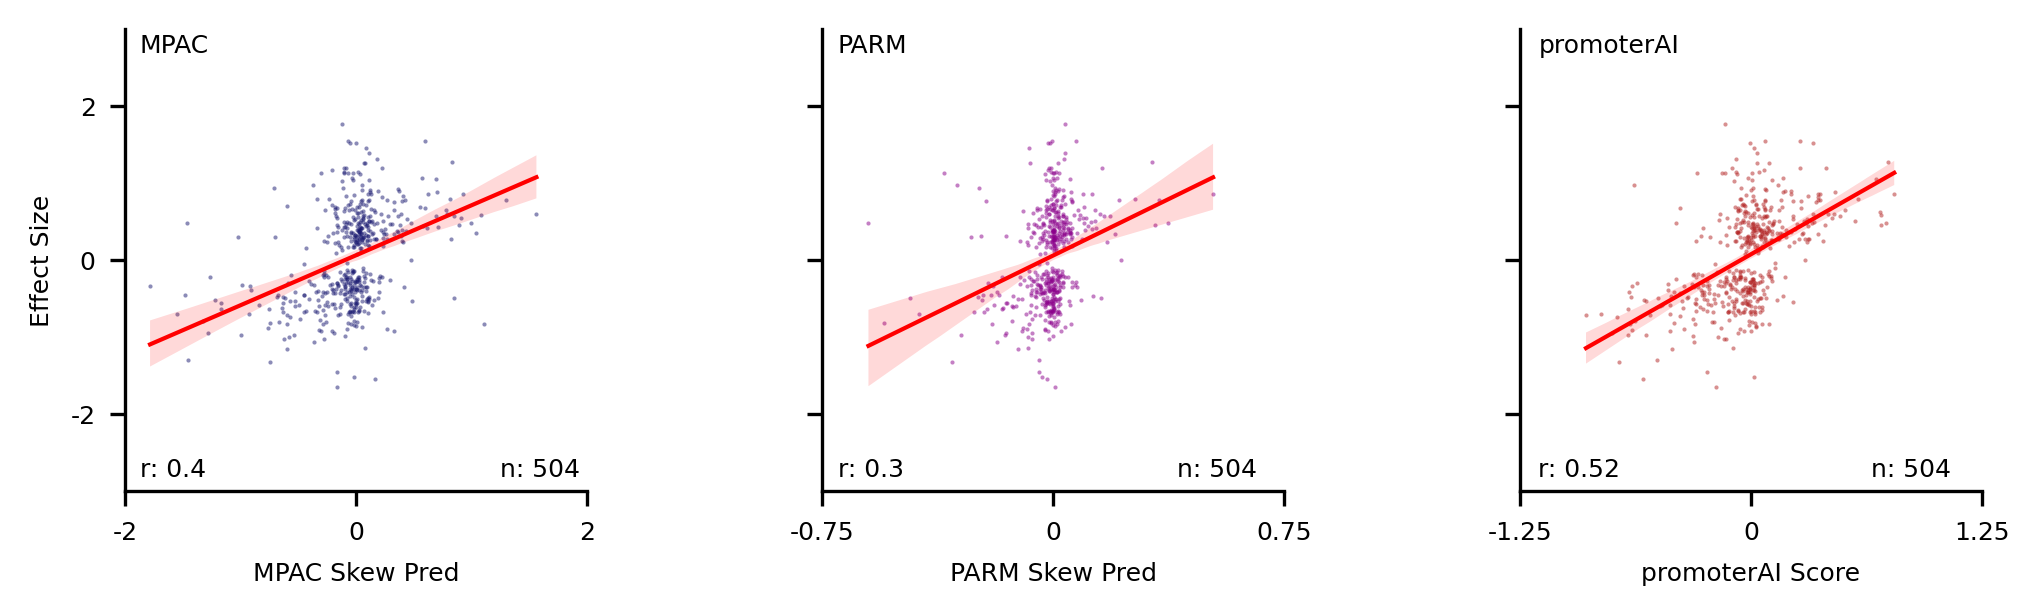

In [14]:
# plot all tissue variants
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# MPAC  Mean #
with sns.axes_style():
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_box_aspect(1)
    sns.regplot(data=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP'], x='mpac_mean_skew', y='slope',
        ci=99, marker="o", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='midnightblue',
                linewidths=0,
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2, 0, 2], [-2, 0, 2], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.annotate(f'n: {len(gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP'])}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['mpac_mean_skew'], 
                                            y=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['slope'])[0], 2)}', xy=(-1.87, -2.8), fontsize = 6)
    plt.annotate('MPAC', xy=(-1.87, 2.7), fontsize = 6)
# PARMC  Mean #
with sns.axes_style():
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_box_aspect(1)
    sns.regplot(data=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP'], x='parm_mean_skew', y='slope',
        ci=99, marker="o", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='darkmagenta',
                linewidths=0,
                alpha=0.5))
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_02.set_xticks([-0.75, 0, 0.75], [-0.75, 0, 0.75], fontsize = 6)
    ax_02.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    ax_02.set_ylabel('')
    plt.ylim((-3, 3))
    plt.annotate(f'n: {len(gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP'])}', xy=(0.4, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['parm_mean_skew'], 
                                            y=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['slope'])[0], 2)}', xy=(-0.7, -2.8), fontsize = 6)
    plt.annotate('PARM', xy=(-.7, 2.7), fontsize = 6)
# MPAC  Mean #
with sns.axes_style():
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_box_aspect(1)
    sns.regplot(data=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP'], x='promoterAI_score', y='slope',
        ci=99, marker="o", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='firebrick',
                linewidths=0,
                alpha=0.5))
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('promoterAI Score', fontsize = 6)
    ax_03.set_xticks([-1.25, 0, 1.25], [-1.25, 0, 1.25], fontsize = 6)
    ax_03.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    ax_03.set_ylabel('')
    plt.annotate(f'n: {len(gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP'])}', xy=(0.65, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['promoterAI_score'], 
                                            y=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['slope'])[0], 2)}', xy=(-1.15, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-1.15, 2.7), fontsize = 6)
sns.despine()
#plt.savefig('plots/eQTL_effect_size_comparison_gtex_v10_v3.pdf')

In [15]:
# make a heatmap of the pearson's correlation for each model with the eQTL betas
# mpac
mpac_corr = round(stats.pearsonr(x=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['mpac_mean_skew'], 
                                 y=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['slope'])[0], 2)
# parm
parm_corr = round(stats.pearsonr(x=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['parm_mean_skew'], 
                                 y=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['slope'])[0], 2)
# promoterAI
pAI_corr = round(stats.pearsonr(x=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['promoterAI_score'], 
                                y=gtex_eQTL_benchmark[gtex_eQTL_benchmark['variant_type'] == 'high_PIP']['slope'])[0], 2)

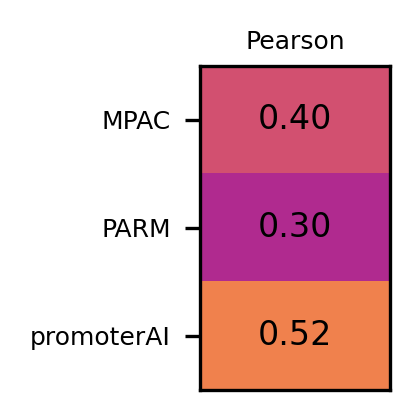

In [16]:
# Combine all data into a dictionary
labels = ['MPAC', 'PARM', 'promoterAI']
data = {
    "Pearson": pd.Series([mpac_corr, parm_corr, pAI_corr], index=labels),
}
testSet = list(data.keys())

fig, axes = plt.subplots(1, 1, figsize=(1.5, 1.5), dpi=300)

cmap = 'plasma'
vmin = 0.0
vmax = 0.75
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
# iterate through tests

ax = axes
correlations = data['Pearson']
heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
ax.set_title('Pearson', fontsize=6, pad=4)
ax.set_xticks([])
ax.set_yticks([])
for j, corr in enumerate(correlations):
    # Adjusted text color for potentially lighter background with 'mako_r'
    text_color = "black"
    ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=8)

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=6)
ax.set_yticks(np.arange(len(labels)), minor=False)
plt.tight_layout()
#plt.savefig('plots/eQTL_beta_corr_summary_gtex_v10_v2.svg')

In [19]:
Counter(gtex_eQTL_benchmark['eQTL_type'])

Counter({'null': 655, 'overexpression': 257, 'underexpression': 247})

In [20]:
# calculate auroc for:
# over/under
# over/null
# under/null
### over/under ###
# make an empty dictionary for storing data
OUdict = {}
# filter for over/under variants
overUnder_vars = gtex_eQTL_benchmark[gtex_eQTL_benchmark['eQTL_type'].isin(['overexpression', 'underexpression'])].copy()
# define prediction columns to iterate through calculating the benchmark
pred_cols = ['promoterAI_score',
             'mpac_mean_skew',
             'parm_mean_skew']
# iterate through pred columns and calculate auroc for each prediction type
for model in pred_cols:
    # get the name of the model from the prediction column
    modName = model.split('_')[0]
    # add a binary column for calculating auroc
    overUnder_vars.loc[:, 'auroc_tf'] = [1 if i == 'overexpression' else 0 for i in overUnder_vars['eQTL_type']]
    # generate auROC curve #
    fpr, tpr, thresh = metrics.roc_curve(overUnder_vars['auroc_tf'],
                                         overUnder_vars[model])
    # generate auROC score #
    auroc_score = metrics.roc_auc_score(overUnder_vars['auroc_tf'],
                                        overUnder_vars[model])
    OUdict[modName] = (fpr, tpr, thresh, auroc_score)
### over/null ###
# make an empty dictionary for storing data
ONdict = {}
# filter for over/null variants
overNull_vars = gtex_eQTL_benchmark[gtex_eQTL_benchmark['eQTL_type'].isin(['overexpression', 'null'])].copy()
# iterate through pred columns and calculate auroc for each prediction type
for model in pred_cols:
    # get the name of the model from the prediction column
    modName = model.split('_')[0]
    # add a binary column for calculating auroc
    overNull_vars.loc[:, 'auroc_tf'] = [1 if i == 'overexpression' else 0 for i in overNull_vars['eQTL_type']]
    # generate auROC curve #
    fpr, tpr, thresh = metrics.roc_curve(overNull_vars['auroc_tf'],
                                         overNull_vars[model])
    # generate auROC score #
    auroc_score = metrics.roc_auc_score(overNull_vars['auroc_tf'],
                                        overNull_vars[model])
    ONdict[modName] = (fpr, tpr, thresh, auroc_score)
### under/null ###
# make an empty dictionary for storing data
UNdict = {}
# filter for over/null variants
underNull_vars = gtex_eQTL_benchmark[gtex_eQTL_benchmark['eQTL_type'].isin(['underexpression', 'null'])].copy()
# iterate through pred columns and calculate auroc for each prediction type
for model in pred_cols:
    # get the name of the model from the prediction column
    modName = model.split('_')[0]
    # add a binary column for calculating auroc
    underNull_vars.loc[:, 'auroc_tf'] = [0 if i == 'underexpression' else 1 for i in underNull_vars['eQTL_type']]
    # generate auROC curve #
    fpr, tpr, thresh = metrics.roc_curve(underNull_vars['auroc_tf'],
                                         underNull_vars[model])
    # generate auROC score #
    auroc_score = metrics.roc_auc_score(underNull_vars['auroc_tf'],
                                        underNull_vars[model])
    UNdict[modName] = (fpr, tpr, thresh, auroc_score)  

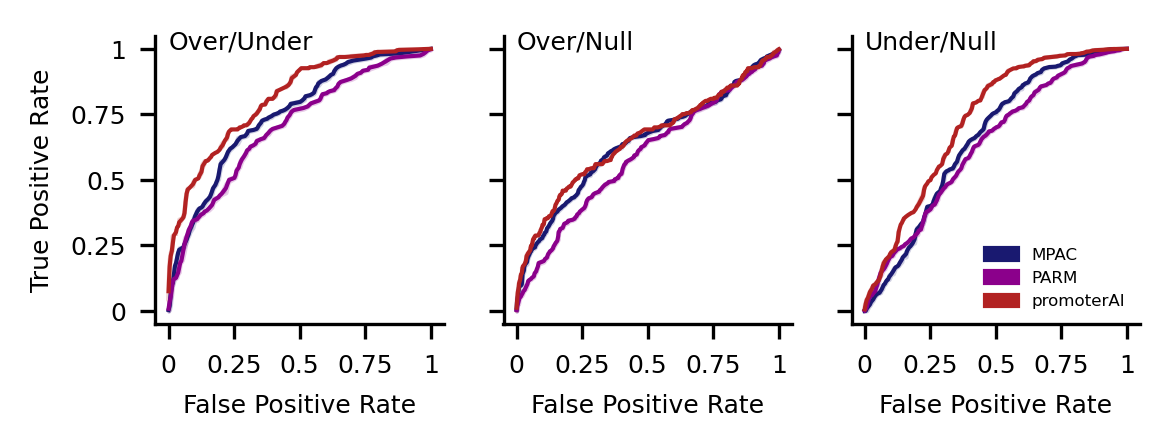

In [21]:
# define swatches for making legend
mpacPatch = mpatches.Patch(color="midnightblue", label='MPAC')
parmPatch = mpatches.Patch(color="darkmagenta", label='PARM')
promoteraiPatch = mpatches.Patch(color="firebrick", label='promoterAI')
rankedPatch = mpatches.Patch(color='teal', label='mpacProAIrankedAvg')
# plot auroc for each test
f = plt.figure(figsize=(4,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# Over/Under #
with sns.axes_style():
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_box_aspect(1)
    # mpac line
    sns.lineplot(
        x = OUdict['mpac'][0], # FPR
        y = OUdict['mpac'][1], # TPR
        color = 'midnightblue',
        linewidth = 1
    )
    # parm line
    sns.lineplot(
        x = OUdict['parm'][0], # FPR
        y = OUdict['parm'][1], # TPR
        color = 'darkmagenta',
        linewidth = 1
    )
    # promoterAI line
    sns.lineplot(
        x = OUdict['promoterAI'][0], # FPR
        y = OUdict['promoterAI'][1], # TPR
        color = 'firebrick',
        linewidth = 1
    )
    ax_01.set_ylabel('True Positive Rate', fontsize = 6)
    ax_01.set_xlabel('False Positive Rate', fontsize = 6)
    ax_01.set_xticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], fontsize = 6)
    ax_01.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], fontsize = 6)
    plt.annotate('Over/Under', xy=(0, 1), fontsize = 6)
# Over/Null #
with sns.axes_style():
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_box_aspect(1)
    # mpac line
    sns.lineplot(
        x = ONdict['mpac'][0], # FPR
        y = ONdict['mpac'][1], # TPR
        color = 'midnightblue',
        linewidth = 1
    )
    # parm line
    sns.lineplot(
        x = ONdict['parm'][0], # FPR
        y = ONdict['parm'][1], # TPR
        color = 'darkmagenta',
        linewidth = 1
    )
    # promoterAI line
    sns.lineplot(
        x = ONdict['promoterAI'][0], # FPR
        y = ONdict['promoterAI'][1], # TPR
        color = 'firebrick',
        linewidth = 1
    )
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('False Positive Rate', fontsize = 6)
    ax_02.set_xticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], fontsize = 6)
    plt.annotate('Over/Null', xy=(0, 1), fontsize = 6)
# Under/Null #
with sns.axes_style():
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_box_aspect(1)
    # mpac line
    sns.lineplot(
        x = UNdict['mpac'][0], # FPR
        y = UNdict['mpac'][1], # TPR
        color = 'midnightblue',
        linewidth = 1
    )
    # parm line
    sns.lineplot(
        x = UNdict['parm'][0], # FPR
        y = UNdict['parm'][1], # TPR
        color = 'darkmagenta',
        linewidth = 1
    )
    # promoterAI line
    sns.lineplot(
        x = UNdict['promoterAI'][0], # FPR
        y = UNdict['promoterAI'][1], # TPR
        color = 'firebrick',
        linewidth = 1
    )
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('False Positive Rate', fontsize = 6)
    ax_03.set_xticks([0, 0.25, 0.5, 0.75, 1], [0, 0.25, 0.5, 0.75, 1], fontsize = 6)
    plt.annotate('Under/Null', xy=(0, 1), fontsize = 6)
    plt.legend(handles=[mpacPatch,
                        parmPatch,
                        promoteraiPatch], 
               loc='lower right',
               fontsize=4,
               frameon=False)
sns.despine()
plt.tight_layout()
#plt.savefig('plots/eQTL_aurocs_gtex_v10_v2.pdf')

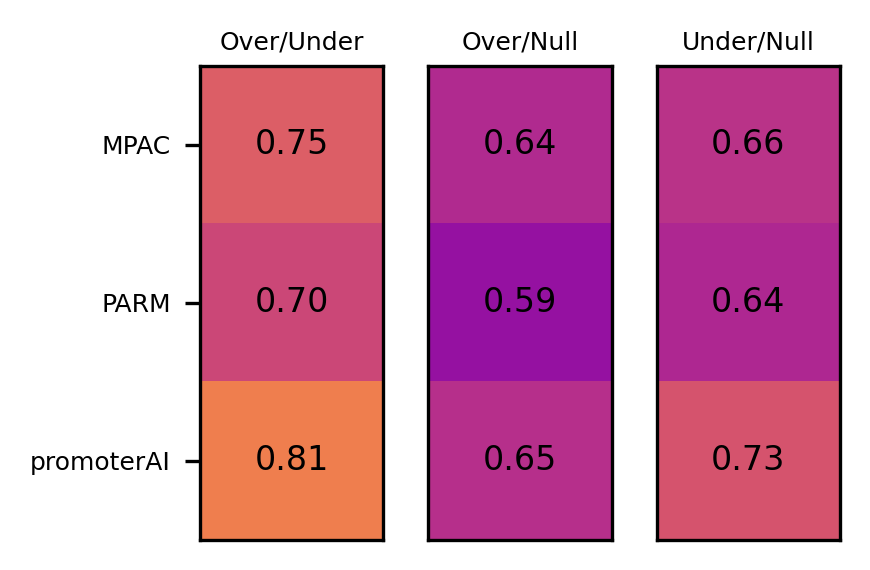

In [22]:
# Combine all data into a dictionary
labels = ['MPAC', 'PARM', 'promoterAI']
data = {
    "Over/Under": pd.Series([OUdict['mpac'][-1], OUdict['parm'][-1], OUdict['promoterAI'][-1]], index=labels),
    "Over/Null": pd.Series([ONdict['mpac'][-1], ONdict['parm'][-1], ONdict['promoterAI'][-1]], index=labels),
    "Under/Null": pd.Series([UNdict['mpac'][-1], UNdict['parm'][-1], UNdict['promoterAI'][-1]], index=labels),
}
testSet = list(data.keys())

fig, axes = plt.subplots(1, 3, figsize=(3, 2), dpi=300)

cmap = 'plasma'
vmin = 0.4
vmax = 1.0
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# iterate through tests
for i, model_name in enumerate(testSet):
    ax = axes[i]
    correlations = data[model_name]
    heatmap_data = correlations.to_numpy().reshape(-1, 1)
    
    im = ax.imshow(heatmap_data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(model_name, fontsize=6, pad=4)
    ax.set_xticks([])
    ax.set_yticks([])
    for j, corr in enumerate(correlations):
        # Adjusted text color for potentially lighter background with 'mako_r'
        text_color = "black"
        ax.text(0, j, f'{corr:.2f}', ha='center', va='center', color=text_color, fontsize=8)

axes[0].set_yticks(np.arange(len(labels)))
axes[0].set_yticklabels(labels, fontsize=6)
axes[0].set_yticks(np.arange(len(labels)), minor=False)
plt.tight_layout()
#plt.savefig('plots/eQTL_auroc_summary_gtex_v10_v2.pdf')